<a href="https://colab.research.google.com/github/KartikIyer27/MlOps-kartik-m25CSA025/blob/Assignment-1/M25CSA025_S_Kartik_Iyer_Ass1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install thop

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torch.cuda.amp import autocast, GradScaler
from thop import profile
import random
import time


In [4]:
DATASET = "MNIST"            # "MNIST" or "FashionMNIST"
MODEL_NAME = "resnet18"      # "resnet18", "resnet50"
BATCH_SIZE = 16              # 16 or 32
LEARNING_RATE = 0.0001        # 0.001 or 0.0001
OPTIMIZER_NAME = "Adam"       # "SGD" or "Adam"
EPOCHS = 3
USE_GPU = True
PIN_MEMORY = True
SEED = 42


In [5]:
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if USE_GPU and torch.cuda.is_available() else "cpu")
print("Running on:", device)


Running on: cuda


In [6]:
transform_resnet = transforms.Compose([
    transforms.Resize((224, 224)),# 64 only for cpu
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])


In [7]:
def load_dataset(name):
    if name == "MNIST":
        dataset = datasets.MNIST("./data", train=True, download=True, transform=transform_resnet)
    else:
        dataset = datasets.FashionMNIST("./data", train=True, download=True, transform=transform_resnet)

    total = len(dataset)
    train_size = int(0.7 * total)
    val_size = int(0.1 * total)
    test_size = total - train_size - val_size

    return random_split(dataset, [train_size, val_size, test_size])


In [8]:
def build_model(name):
    if name == "resnet18":
        model = models.resnet18(weights=None)
    elif name == "resnet34":
        model = models.resnet34(weights=None)
    elif name == "resnet50":
        model = models.resnet50(weights=None)
    else:
        raise ValueError("Invalid model name")

    model.fc = nn.Linear(model.fc.in_features, 10)
    return model.to(device)


In [9]:
def build_optimizer(model):
    optimizers = {
        "SGD": optim.SGD(
            model.parameters(),
            lr=LEARNING_RATE,
            momentum=0.9
        ),
        "Adam": optim.Adam(
            model.parameters(),
            lr=LEARNING_RATE
        )
    }
    return optimizers[OPTIMIZER_NAME]


In [10]:
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total, correct, loss_sum = 0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        with autocast():
            outputs = model(x)
            loss = criterion(outputs, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_sum += loss.item()
        correct += outputs.argmax(1).eq(y).sum().item()
        total += y.size(0)

    return loss_sum / len(loader), correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total, correct, loss_sum = 0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)

            loss_sum += loss.item()
            correct += outputs.argmax(1).eq(y).sum().item()
            total += y.size(0)

    return loss_sum / len(loader), correct / total


In [11]:
def calculate_flops(model_name):
    model = build_model(model_name)
    model.eval()

    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    flops, params = profile(model, inputs=(dummy_input,), verbose=False)

    return round(flops / 1e9, 3), round(params / 1e6, 3)


In [12]:
train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []


In [13]:
train_ds, val_ds, test_ds = load_dataset(DATASET)
# model training was taking too much time on cpu so i reduced the size of data
if device.type == "cpu":
    from torch.utils.data import Subset


    train_ds = Subset(train_ds, range(8000))
    val_ds   = Subset(val_ds, range(2000))
    test_ds  = Subset(test_ds, range(2000))

    print("CPU mode: using reduced dataset")
    print("Train size:", len(train_ds))
    print("Val size  :", len(val_ds))
    print("Test size :", len(test_ds))



train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=PIN_MEMORY)

model = build_model(MODEL_NAME)
criterion = nn.CrossEntropyLoss()
optimizer = build_optimizer(model)
scaler = GradScaler(enabled=(device.type == "cuda"))

best_val_acc = 0
best_state = None


if device.type == "cuda":
    torch.cuda.synchronize()

start_time = time.time() #time start

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, scaler
    )
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)
    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = model.state_dict()


if device.type == "cuda":
    torch.cuda.synchronize()

end_time = time.time()  #end time
training_time = end_time - start_time #total time


model.load_state_dict(best_state)
_, test_acc = evaluate(model, test_loader, criterion)

flops, params = calculate_flops(MODEL_NAME)


100%|██████████| 9.91M/9.91M [00:00<00:00, 19.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.66MB/s]
/tmp/ipython-input-990813928.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device.type == "cuda"))
/tmp/ipython-input-1183819977.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/3 | Train Acc: 0.9618 | Val Acc: 0.9893
Epoch 2/3 | Train Acc: 0.9858 | Val Acc: 0.9820
Epoch 3/3 | Train Acc: 0.9892 | Val Acc: 0.9930


In [14]:
print("\n================ FINAL RESULT =================")
print("Dataset        :", DATASET)
print("Model          :", MODEL_NAME)
print("Batch Size     :", BATCH_SIZE)
print("Optimizer      :", OPTIMIZER_NAME)
print("Learning Rate  :", LEARNING_RATE)
print("Device         :", device)
print("Epochs         :", EPOCHS)
print("Training Time  :", round(training_time*100, 2), "seconds")
print("Test Accuracy  :", round(test_acc * 100, 2), "%")
print("FLOPs          :", flops, "GFLOPs")
print("Parameters     :", params, "Million")



================ FINAL RESULT =================
Dataset        : MNIST
Model          : resnet18
Batch Size     : 16
Optimizer      : Adam
Learning Rate  : 0.0001
Device         : cuda
Epochs         : 3
Training Time  : 42693.1 seconds
Test Accuracy  : 99.17 %
FLOPs          : 1.824 GFLOPs
Parameters     : 11.182 Million


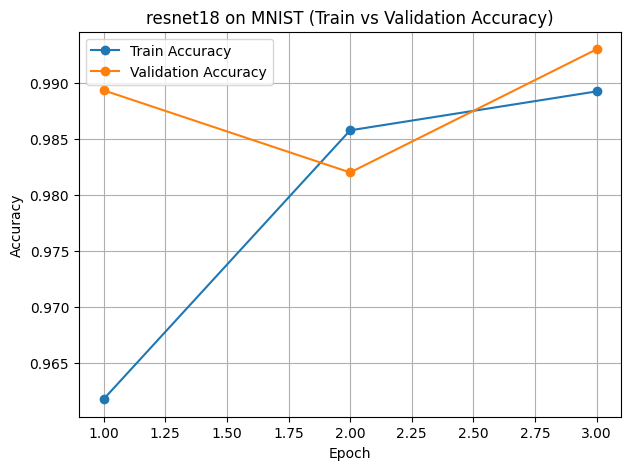

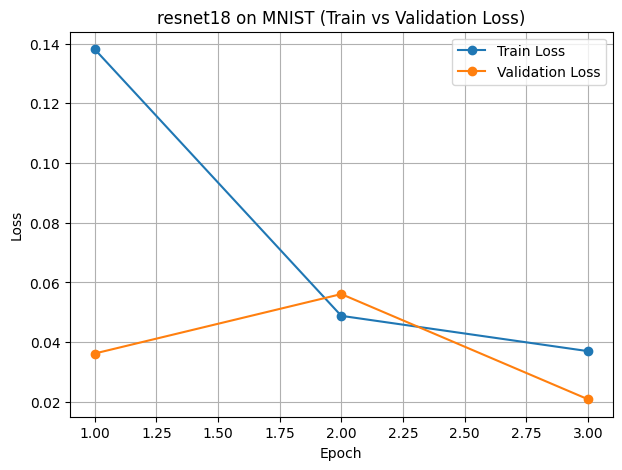

In [15]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(7,5))
plt.plot(epochs_range, train_acc_list, label="Train Accuracy", marker="o")
plt.plot(epochs_range, val_acc_list, label="Validation Accuracy", marker="o")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_NAME} on {DATASET} (Train vs Validation Accuracy)")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(7,5))
plt.plot(epochs_range, train_loss_list, label="Train Loss", marker="o")
plt.plot(epochs_range, val_loss_list, label="Validation Loss", marker="o")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{MODEL_NAME} on {DATASET} (Train vs Validation Loss)")
plt.legend()
plt.grid(True)
plt.show()


SVM


In [15]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np


In [16]:
def dataset_to_numpy(dataset, max_samples=6000):
    X, y = [], []
    for i, (img, label) in enumerate(dataset):
        if i >= max_samples:
            break
        X.append(img.view(-1).numpy())  # flatten
        y.append(label)
    return np.array(X), np.array(y)


In [17]:
def run_svm_experiment(dataset_name, kernel, C=1.0, degree=3):
    print(f"\nRunning SVM | Dataset={dataset_name} | Kernel={kernel}")

    # Load dataset (NO resize, original 28x28)
    transform = transforms.ToTensor()

    if dataset_name == "MNIST":
        train_ds = datasets.MNIST("./data", train=True, download=True, transform=transform)
        test_ds  = datasets.MNIST("./data", train=False, download=True, transform=transform)
    else:
        train_ds = datasets.FashionMNIST("./data", train=True, download=True, transform=transform)
        test_ds  = datasets.FashionMNIST("./data", train=False, download=True, transform=transform)

    X_train, y_train = dataset_to_numpy(train_ds)
    X_test, y_test   = dataset_to_numpy(test_ds, max_samples=2000)

    svm = SVC(kernel=kernel, C=C, degree=degree)

    start = time.time()
    svm.fit(X_train, y_train)
    train_time_ms = (time.time() - start) * 1000

    y_pred = svm.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Accuracy: {acc*100:.2f}%")
    print(f"Training Time: {train_time_ms:.2f} ms")

    return acc, train_time_ms


In [18]:

run_svm_experiment("MNIST", kernel="poly", C=1.0, degree=3)
run_svm_experiment("MNIST", kernel="rbf", C=1.0)


run_svm_experiment("FashionMNIST", kernel="poly", C=1.0, degree=3)
run_svm_experiment("FashionMNIST", kernel="rbf", C=1.0)



Running SVM | Dataset=MNIST | Kernel=poly
Accuracy: 91.70%
Training Time: 3506.52 ms

Running SVM | Dataset=MNIST | Kernel=rbf
Accuracy: 93.15%
Training Time: 3661.45 ms

Running SVM | Dataset=FashionMNIST | Kernel=poly


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 212kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.94MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.0MB/s]


Accuracy: 81.55%
Training Time: 3613.60 ms

Running SVM | Dataset=FashionMNIST | Kernel=rbf
Accuracy: 85.15%
Training Time: 3266.09 ms


(0.8515, 3266.087055206299)